# Intrinsic Volume Approximations with Real Flag Matrix Manifolds and Matern Kernels

In [1]:
import rmatqmcpy 
import torch
import numpy as np 
import qmcpy as qp
import agsutil
import time
import pandas as pd
import os
import matplotlib
import scipy
from matplotlib import pyplot
torch.set_default_dtype(torch.float64)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("torch device = %s"%DEVICE)
MPLP = agsutil.mpl_setup()
agsutil.print_data_signatures(MPLP,"MPLP",verbose_indent=0)

torch device = cpu
MPLP['PW'] = 30
MPLP['FS'] = 30
MPLP['COLORS'] a list of length 10
MPLP['LINESTYLES'] a list of length 10
MPLP['MARKERS'] a list of length 12


In [2]:
body = "cube" # cube,random
p = 2 # 2,3
n = 3 # 3,5
nu = 1/2 # 3/2,1/2
log2_N_ref = 25
log2_N_max = 11 # 12,11
log2_N_rho = 11
trials = 100
assert n>p
print("n = %d"%n)
print("nu = %.1f"%nu)
print("log2_N_ref = %d"%log2_N_ref)
print("log2_N_max = %s"%log2_N_max)
print("log2_N_rho = %s"%log2_N_rho)
if body=="cube": # cube [-1,1]^n
    Z = torch.tensor([[2*int(b)-1 for b in np.binary_repr(k,width=n)] for k in range(2**n)],dtype=float,device=DEVICE)
    Tk_true = (agsutil.comb(torch.tensor(n,device=DEVICE),torch.arange(n+1,device=DEVICE))*2**torch.arange(n+1,device=DEVICE))[:(1+p)]
elif body=="random": # convex hull of random normal points
    Z = torch.randn(10,n,device=DEVICE)
    Tk_true = torch.nan*torch.ones(n+1,device=DEVICE)
else: raise Exception("invalid body = %s"%body)
print("Z.shape = %s"%str(tuple(Z.shape)))
print("Z = \n%s"%str(Z))
print("Tk_true = %s"%Tk_true)
nvec = torch.arange(n+1,device=DEVICE)
logkappa = (nvec/2)*np.log(np.pi)-torch.lgamma(nvec/2+1)
print("logkappa.shape = %s"%str(tuple(logkappa.shape)))
print("kappa = torch.exp(logkappa) = %s"%torch.exp(logkappa))
coeff_Tk = torch.exp(agsutil.logcomb(nvec[-1],nvec)+logkappa[-1]-logkappa-torch.flip(logkappa,dims=(0,)))
print("coeff_Tk.shape = %s"%str(tuple(coeff_Tk.shape)))
print("coeff_Tk = %s"%coeff_Tk)
delta = torch.tensor([max(p+1-i,1) for i in range(n)],device=DEVICE,dtype=float)
delta = delta/torch.linalg.norm(delta)
_,_inv_m,m = delta.unique(return_inverse=True,return_counts=True)
assert (_inv_m[:-1]>=_inv_m[1:]).all()
rand_manifold = lambda *args,**kwargs: rmatqmcpy.rand_flag_R(*args,delta=delta,**kwargs)
d = int(1/2*(n**2-(m**2).sum()))
r = int(n**2)
decomp_kwarg = "rand_On"
decomp_map = {"QR": rmatqmcpy.rand_On_QR,"eig": rmatqmcpy.rand_On_eig}
s = nu+d/2
print("d = %d"%d)
print("r = %d"%r)
print("s = %s"%s)
print("s/d = %s"%(s/d))

n = 3
nu = 0.5
log2_N_ref = 25
log2_N_max = 11
log2_N_rho = 11
Z.shape = (8, 3)
Z = 
tensor([[-1., -1., -1.],
        [-1., -1.,  1.],
        [-1.,  1., -1.],
        [-1.,  1.,  1.],
        [ 1., -1., -1.],
        [ 1., -1.,  1.],
        [ 1.,  1., -1.],
        [ 1.,  1.,  1.]])
Tk_true = tensor([ 1,  6, 12])
logkappa.shape = (4,)
kappa = torch.exp(logkappa) = tensor([1.0000, 2.0000, 3.1416, 4.1888])
coeff_Tk.shape = (4,)
coeff_Tk = tensor([1.0000, 2.0000, 2.0000, 1.0000])
d = 3
r = 9
s = 2.0
s/d = 0.6666666666666666


In [3]:
x_ref = rand_manifold(N=2**0,n=n,seed=107,qp_unif_gen=qp.Net)
y_ref = rand_manifold(N=2**log2_N_ref,n=n,seed=101,qp_unif_gen=qp.Net)
N_rho = 2**log2_N_rho
fnorms = torch.linalg.norm(y_ref[:N_rho,None,:,:]-y_ref[None,:N_rho,:,:],dim=(-2,-1)).real
rho = fnorms[*torch.tril_indices(N_rho,N_rho,-1)].median().item()
print("rho = %.2e"%rho)
kernel = rmatqmcpy.KernelMatern(nu=nu,rho=rho)
kmean = kernel(x_ref[:,None,:,:],y_ref[None,:,:,:]).mean().item()
print("kmean = %.20f"%kmean)
del x_ref,y_ref,N_rho,fnorms

rho = 5.35e-01
kmean = 0.39136662154130041902


In [4]:
def approx_intrinsic_volumes(q, w):
    n = w.size(0)
    vols = torch.ones((1+p,n),device=DEVICE)
    for k in range(1,p+1):
        Zk = torch.einsum("lj,ijk->ilk",Z,q[...,:k])
        if k==1:
            vols[k,:] = Zk[...,0].amax(1)-Zk[...,0].amin(1)
            continue
        for i in range(n):
            vols[k,i] = scipy.spatial.ConvexHull(Zk[i].cpu().numpy()).volume
    Vi_hat = coeff_Tk[:(1+p)]*(vols*w).sum(-1)
    return Vi_hat

In [5]:
genf_ld_optw_decomp = [
    [r"IID $\mathcal{X}$ ~ Equal $\boldsymbol{w}$",     False,      False,      "QR"],
    [r"IID $\mathcal{X}$ ~ Opt $\boldsymbol{w}$",       False,      True,       "QR"],
    # [r"QR LD $\mathcal{X}$ ~ Equal $\boldsymbol{w}$",   True,       False,      "QR"], 
    # [r"Eig LD $\mathcal{X}$ ~ Equal $\boldsymbol{w}$",  True,       False,      "eig"], 
]
N = 2**torch.arange(2,log2_N_max+1)
seeds = [i for i in range(trials)]
wces = torch.nan*torch.empty((len(genf_ld_optw_decomp),len(N),trials))
Tk_hats = torch.nan*torch.empty((len(genf_ld_optw_decomp),len(N),trials,1+p))
errors = torch.nan*torch.empty((len(genf_ld_optw_decomp),len(N),trials,1+p))
t0 = time.perf_counter()
for i,(key,ld,optw,decomp) in enumerate(genf_ld_optw_decomp):
    print(key)
    qp_unif_gen = qp.Net if ld else qp.IIDStdUniform
    rand_decomp = decomp_map[decomp]
    kwargs_rand_manifold = {"qp_unif_gen":qp_unif_gen,decomp_kwarg:rand_decomp}
    for j in range(len(N)):
        print("    N = %d"%N[j])
        for t in range(trials):
            q = rand_decomp(N=N[j],n=n,k=n,seed=seeds[t],device=DEVICE,qp_unif_gen=qp_unif_gen)
            x = torch.einsum("...ij,...j,...kj->...ik",q,delta.to(q.dtype),q)
            if optw:
                w,wce2_p_kmean = rmatqmcpy.opt_weights_sum_1(x,kernel)
            else:
                w = torch.ones(N[j],device=DEVICE)/N[j]
                kmat = kernel(x[:,None,:,:],x[None,:,:,:])
                wce2_p_kmean = torch.einsum("...i,...ij,...j->...",w,kmat,w) # (...,)
            wces[i,j,t] = np.sqrt(max(0,float(wce2_p_kmean.cpu()-kmean)))
            Tk_hats[i,j,t,:] = approx_intrinsic_volumes(q=q,w=w)
            errors[i,j,t,:] = torch.abs(Tk_hats[i,j,t,:]-Tk_true.cpu())
            with np.printoptions(formatter={"float":lambda x: "%.1e"%x}):
                print("        trial %-10d time %-10.1f Tk_hat = %-40s error = %-40s wce = %.1e"%(t,time.perf_counter()-t0,Tk_hats[i,j,t,:].cpu().numpy(),errors[i,j,t,:] .cpu().numpy(),wces[i,j,t]))

IID $\mathcal{X}$ ~ Equal $\boldsymbol{w}$
    N = 4
        trial 0          time 0.0        Tk_hat = [1.0e+00 5.8e+00 1.2e+01]                error = [0.0e+00 2.0e-01 1.1e-01]                wce = 4.0e-01
        trial 1          time 0.0        Tk_hat = [1.0e+00 6.0e+00 1.2e+01]                error = [0.0e+00 1.5e-02 2.2e-01]                wce = 4.3e-01
        trial 2          time 0.0        Tk_hat = [1.0e+00 6.1e+00 1.2e+01]                error = [0.0e+00 5.3e-02 3.4e-01]                wce = 3.8e-01
        trial 3          time 0.0        Tk_hat = [1.0e+00 5.9e+00 1.2e+01]                error = [0.0e+00 1.1e-01 1.5e-01]                wce = 4.6e-01
        trial 4          time 0.0        Tk_hat = [1.0e+00 5.9e+00 1.2e+01]                error = [0.0e+00 1.2e-01 2.8e-01]                wce = 4.0e-01
        trial 5          time 0.0        Tk_hat = [1.0e+00 5.7e+00 1.1e+01]                error = [0.0e+00 3.3e-01 9.2e-01]                wce = 3.8e-01
        trial 6        

In [6]:
data = {
    "names": [key for key,*_ in genf_ld_optw_decomp],
    "Tk_hats": Tk_hats,
    "errors": errors,
    "wces": wces,
    "n": n, 
    "nu": nu, 
    "d": d, 
    "r": r, 
    "s": s,
    "N": N,
    "nu_str": kernel.nu_str,
    "p": p,
    "body": body,
}
data["delta"] = delta
data["m"] = m
torch.save(data,"./out/data/IV.n%d.d%d.nu%s.pt"%(n,d,nu))

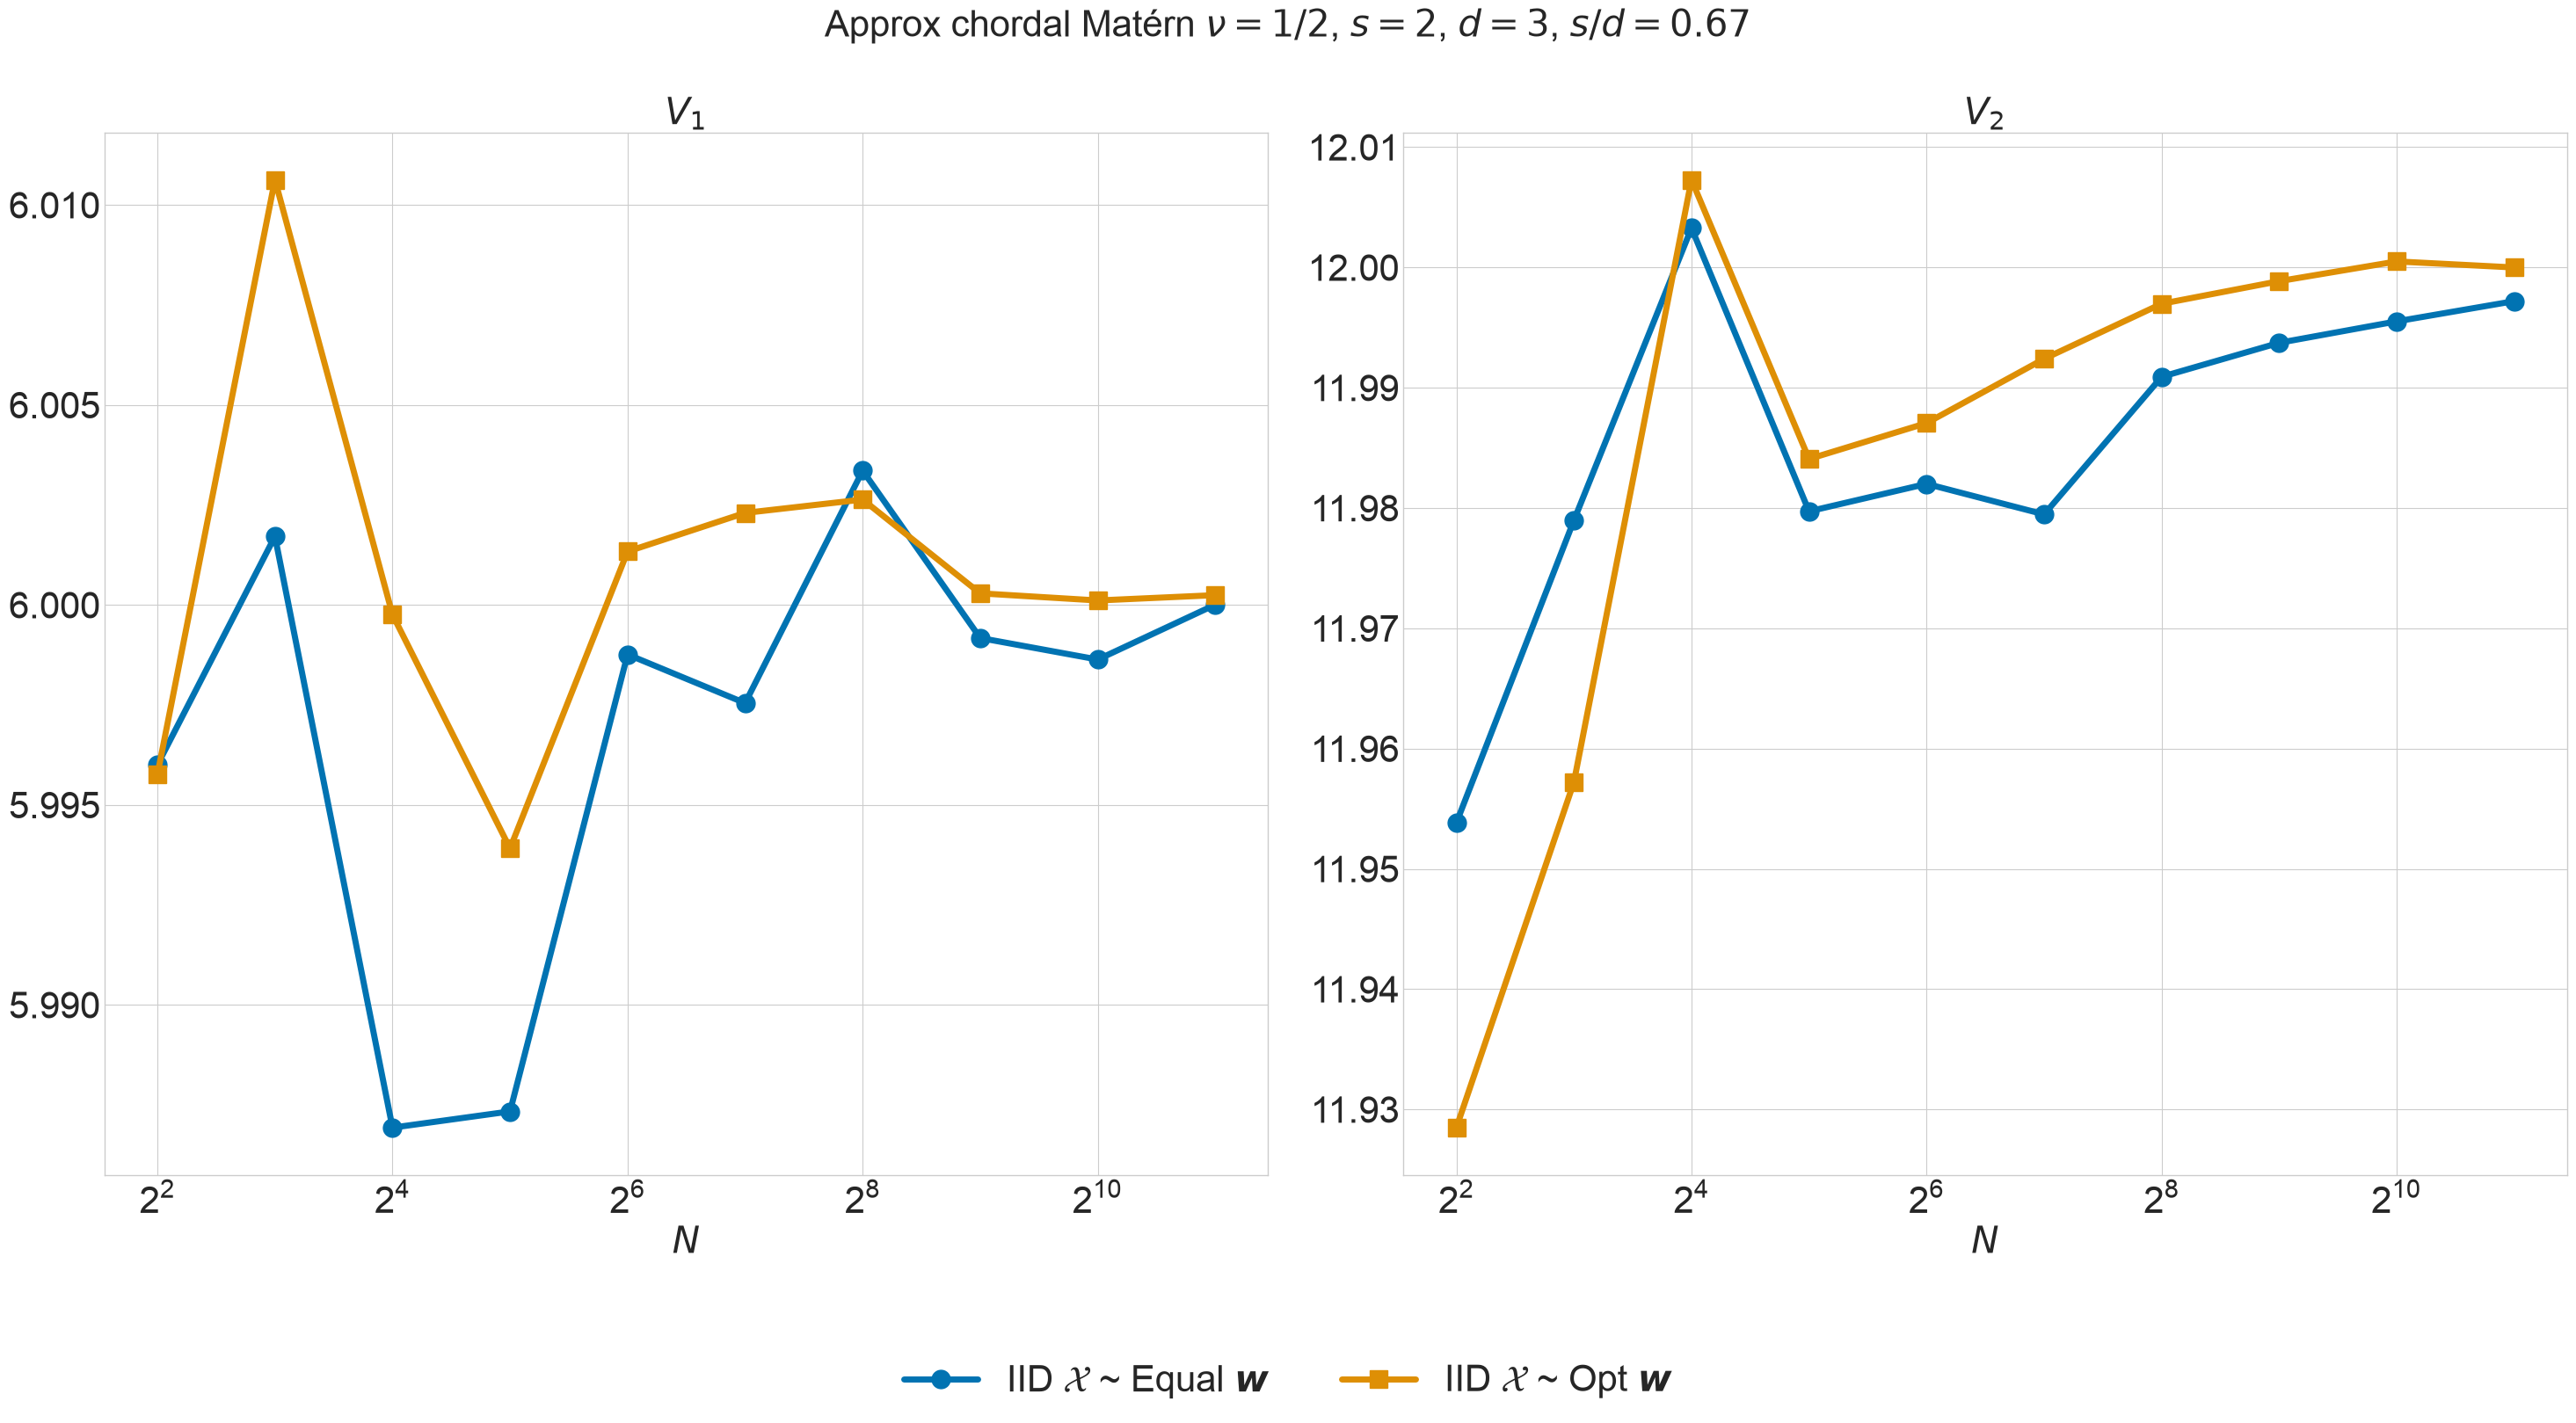

In [7]:
TK_hats_means = Tk_hats.mean(-2)
fig,ax = pyplot.subplots(nrows=1,ncols=p,figsize=(MPLP["PW"],MPLP["PW"]/p),sharex=True,sharey=False)
for i,(key,*_) in enumerate(genf_ld_optw_decomp):
    for k in range(1,p+1):
        ax[k-1].plot(N,TK_hats_means[i,:,k],color=MPLP["COLORS"][i],marker=MPLP["MARKERS"][i],label=key if k==1 else None)
for k in range(1,p+1):
    ax[k-1].set_xscale("log",base=2)
    ax[k-1].set_xlabel(r"$N$")
    ax[k-1].set_title(r"$V_{%d}$"%k)
fig.legend(frameon=False,ncols=4,loc="lower center",bbox_to_anchor=(.5,-.1))
assert s==np.inf or s%1 in [0,1/2]
if s==np.inf:
    s_str = r"\infty"
elif s%1==0:
    s_str = r"%d"%s 
elif s%1==1/2:
    s_str = r"%d/2"%(2*s)
fig.suptitle(r"Approx chordal Matérn "+kernel.nu_str+r", $s = %s$"%s_str+r", $d=%d$"%d+r", $s/d = %.2f$"%(s/d))
fig.tight_layout()
# fig.savefig("./out/Vk.approx.%s.n%d.d%d.nu%s.png"%(body,n,d,nu),bbox_inches="tight")

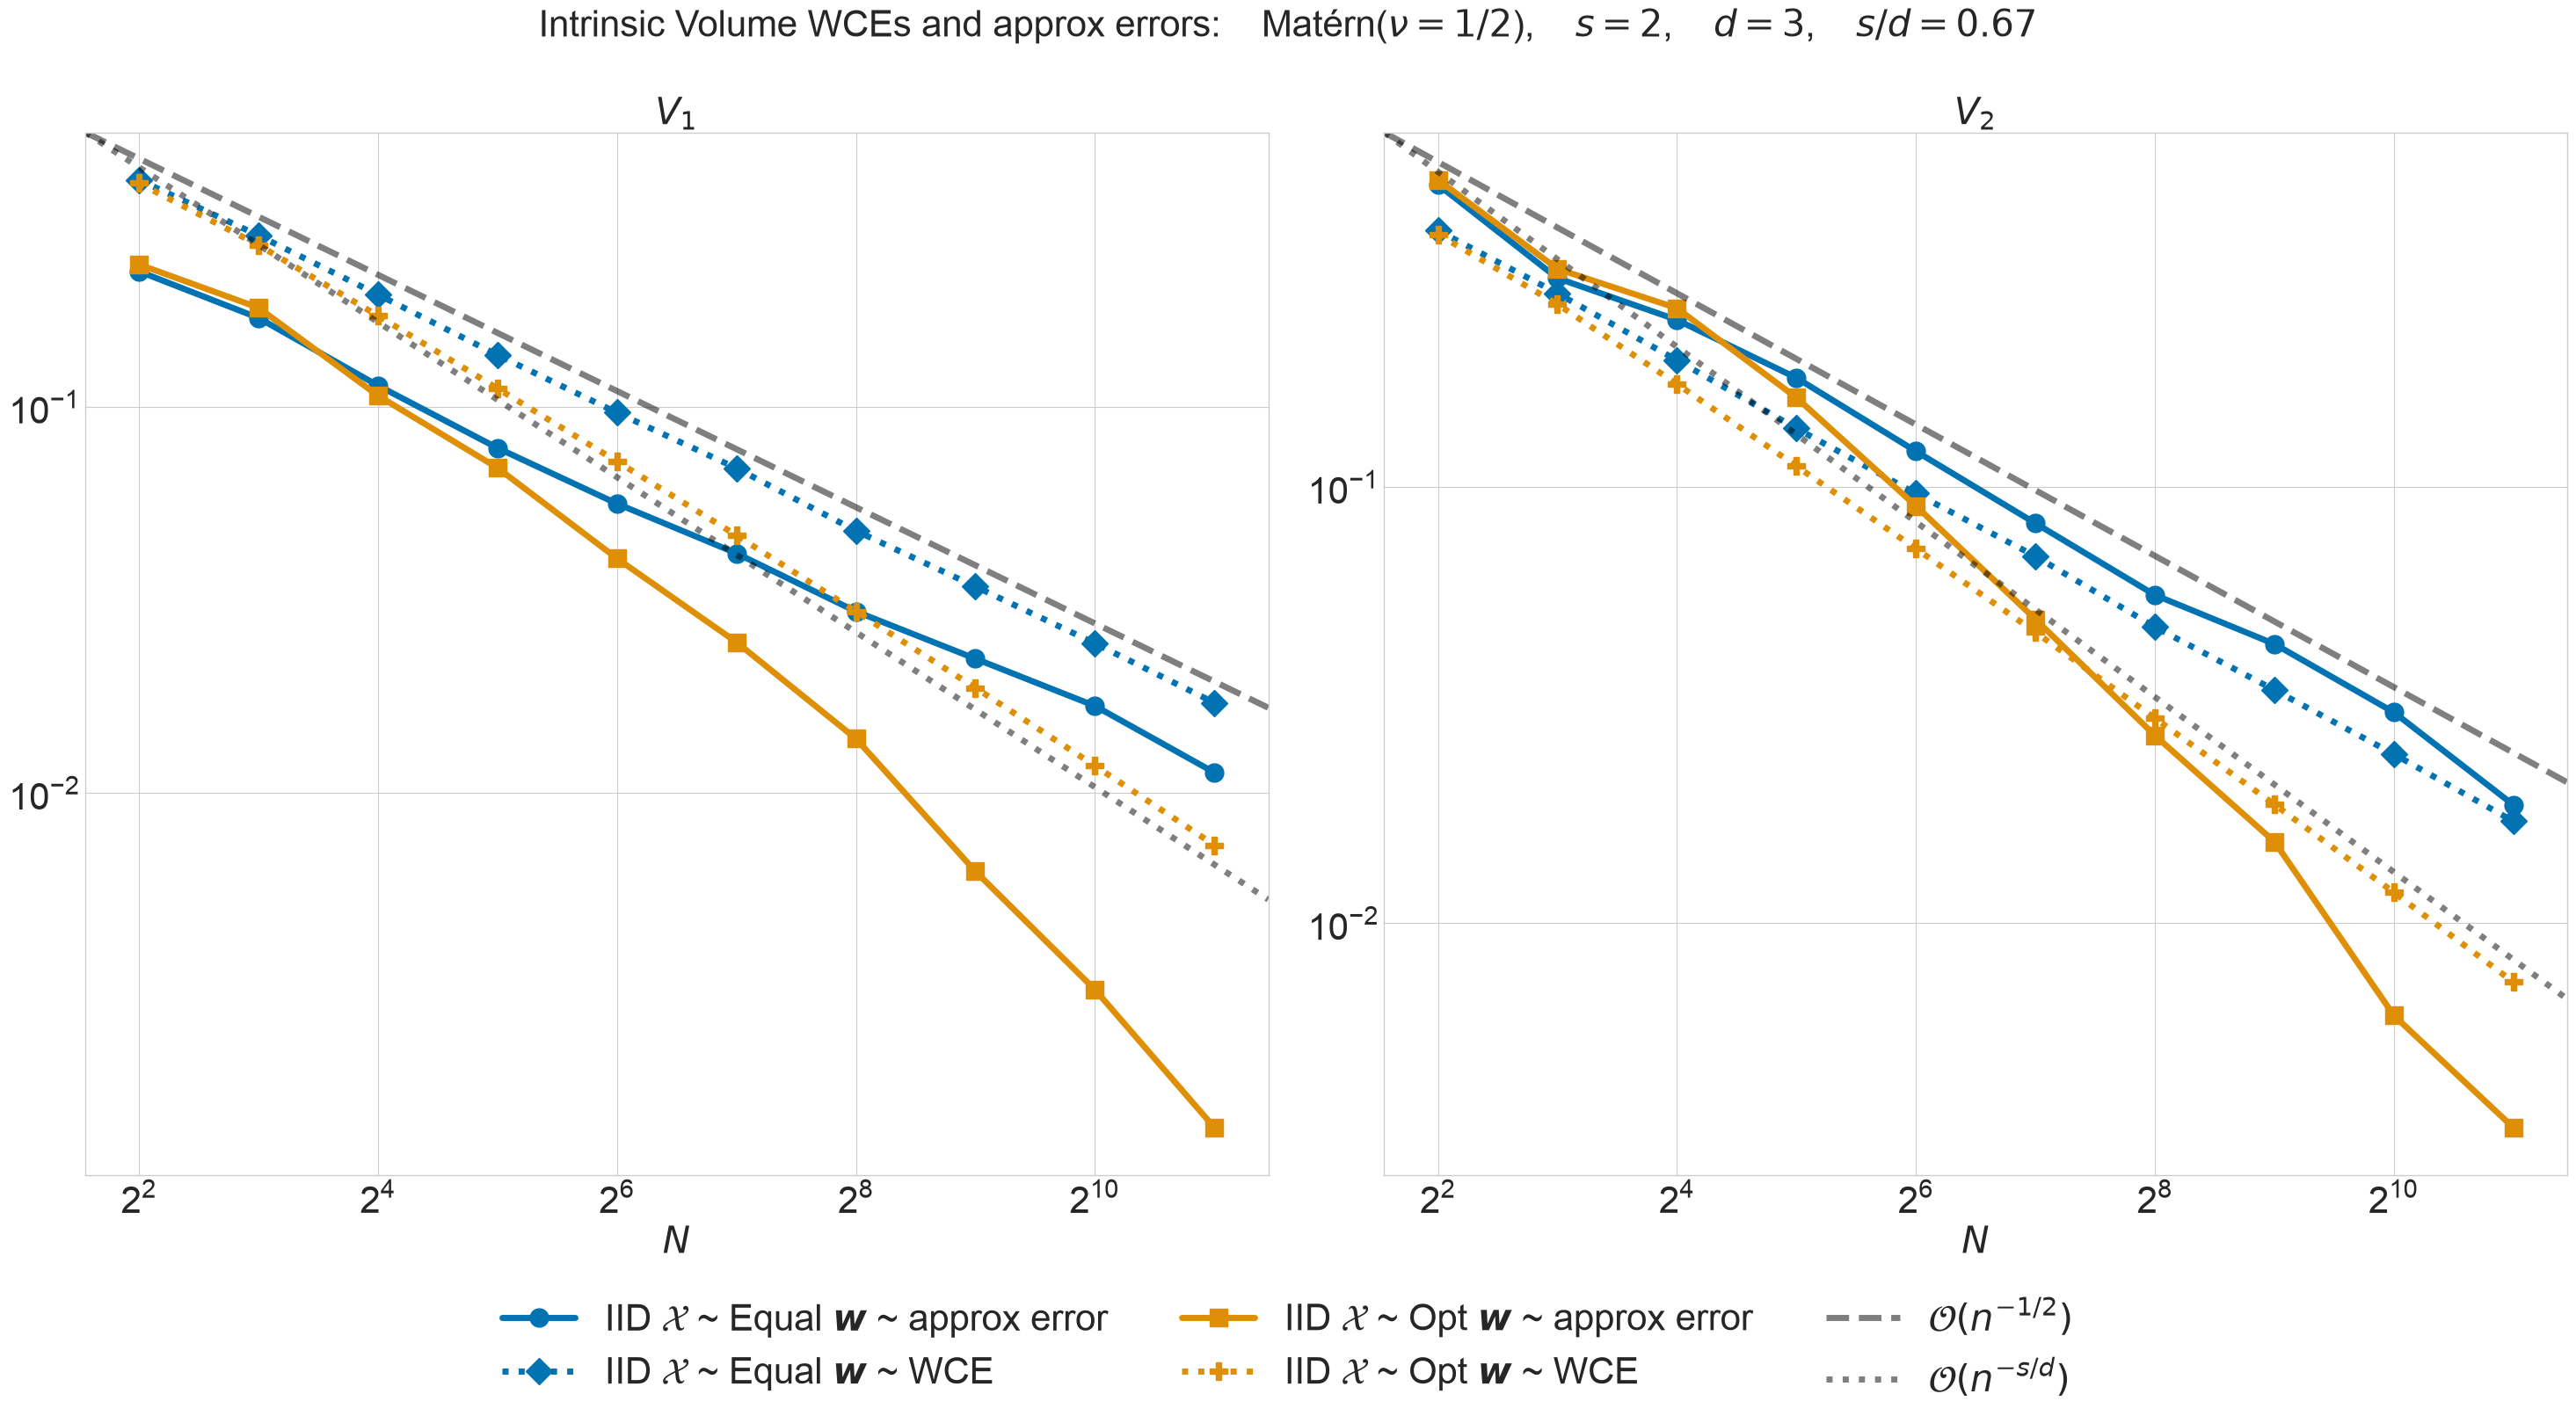

In [8]:
errors_mean = errors.mean(-2)
wces_means = wces.mean(-1)
fig,ax = pyplot.subplots(nrows=1,ncols=p,figsize=(MPLP["PW"],MPLP["PW"]/p),sharex=True,sharey=False)
for i,(key,*_) in enumerate(genf_ld_optw_decomp):
    for k in range(1,p+1):
        ax[k-1].plot(N,errors_mean[i,:,k],color=MPLP["COLORS"][i],marker=MPLP["MARKERS"][i],label=key+" ~ approx error" if k==1 else None)
        ax[k-1].plot(N,wces_means[i],color=MPLP["COLORS"][i],marker=MPLP["MARKERS"][i+len(genf_ld_optw_decomp)],label=key+ " ~ WCE" if k==1 else None,linestyle="dotted")
for k in range(1,p+1):
    ax[k-1].set_xscale("log",base=2)
    ax[k-1].set_yscale("log",base=10)
    ax[k-1].set_xlabel(r"$N$")
    ax[k-1].set_title(r"$V_{%d}$"%k)
    xmin,xmax = ax[k-1].get_xlim()
    ymin,ymax = ax[k-1].get_ylim()
    ax[k-1].set_xlim([xmin,xmax])
    ax[k-1].set_ylim([ymin,ymax])
    ax[k-1].axline([xmin,ymax],[2*xmin,2**(-1/2)*ymax],color="k",alpha=0.5,linestyle="dashed",label=r"$\mathcal{O}(n^{-1/2})$" if k==1 else None)
    ax[k-1].axline([xmin,ymax],[2*xmin,2**(-s/d)*ymax],color="k",alpha=0.5,linestyle="dotted",label=r"$\mathcal{O}(n^{-s/d})$" if k==1 else None)
fig.legend(frameon=False,ncols=3,loc="lower center",bbox_to_anchor=(.5,-.1))
assert s==np.inf or s%1 in [0,1/2]
if s==np.inf:
    s_str = r"\infty"
elif s%1==0:
    s_str = r"%d"%s 
elif s%1==1/2:
    s_str = r"%d/2"%(2*s)
fig.suptitle(r"Intrinsic Volume WCEs and approx errors:    Matérn(%s)"%kernel.nu_str+r",    $s = %s$"%s_str+r",    $d=%d$"%d+r",    $s/d = %.2f$"%(s/d))
fig.tight_layout()
fig.savefig("./out/Tk.error.%s.n%d.d%d.nu%s.png"%(body,n,d,nu),bbox_inches="tight")

In [9]:
wces_df = pd.DataFrame(wces.mean(-1).T,columns=[name for (name,*_) in genf_ld_optw_decomp])
wces_df['N'] = N
wces_df = wces_df.set_index('N')
print(r"WCEs")
wces_df

WCEs


,IID $\mathcal{X}$ ~ Equal $\boldsymbol{w}$,IID $\mathcal{X}$ ~ Opt $\boldsymbol{w}$
N,,
4,0.387621,0.379848
8,0.278088,0.262628
16,0.195409,0.172350
32,0.136307,0.111694
64,0.096670,0.072276
128,0.069413,0.046504
256,0.047775,0.029532
512,0.034263,0.018724
1024,0.024418,0.011767


In [10]:
for k in range(1,p+1):
    Tk_hats_df_k = pd.DataFrame(Tk_hats[...,k].mean(-1).T,columns=[name for (name,*_) in genf_ld_optw_decomp])
    Tk_hats_df_k['N'] = N
    Tk_hats_df_k = Tk_hats_df_k.set_index('N')
    print(r"Tk_hats for k=%d with true value %.5e"%(k,Tk_true[k]))
    display(Tk_hats_df_k);

Tk_hats for k=1 with true value 6.00000e+00


,IID $\mathcal{X}$ ~ Equal $\boldsymbol{w}$,IID $\mathcal{X}$ ~ Opt $\boldsymbol{w}$
N,,
4,5.996000,5.995754
8,6.001715,6.010632
16,5.986931,5.999759
32,5.987336,5.993912
64,5.998762,6.001336
128,5.997546,6.002302
256,6.003359,6.002636
512,5.999174,6.000291
1024,5.998635,6.000112


Tk_hats for k=2 with true value 1.20000e+01


,IID $\mathcal{X}$ ~ Equal $\boldsymbol{w}$,IID $\mathcal{X}$ ~ Opt $\boldsymbol{w}$
N,,
4,11.953832,11.928484
8,11.978978,11.957213
16,12.003279,12.007293
32,11.979726,11.984077
64,11.982009,11.987063
128,11.979473,11.992405
256,11.990913,11.996985
512,11.993738,11.998863
1024,11.995521,12.000503


In [11]:
for k in range(1,p+1):
    errors_df_k = pd.DataFrame(errors[...,k].mean(-1).T,columns=[name for (name,*_) in genf_ld_optw_decomp])
    errors_df_k['N'] = N
    errors_df_k = errors_df_k.set_index('N')
    print(r"errors for k=%d"%k)
    display(errors_df_k);

errors for k=1


,IID $\mathcal{X}$ ~ Equal $\boldsymbol{w}$,IID $\mathcal{X}$ ~ Opt $\boldsymbol{w}$
N,,
4,0.224501,0.233951
8,0.170078,0.180742
16,0.113621,0.107010
32,0.078298,0.069546
64,0.056174,0.040525
128,0.041778,0.024593
256,0.029538,0.013832
512,0.022281,0.006268
1024,0.016813,0.003096


errors for k=2


,IID $\mathcal{X}$ ~ Equal $\boldsymbol{w}$,IID $\mathcal{X}$ ~ Opt $\boldsymbol{w}$
N,,
4,0.493847,0.506488
8,0.301307,0.316449
16,0.241716,0.257155
32,0.177972,0.160337
64,0.120802,0.090533
128,0.082619,0.049783
256,0.056576,0.026950
512,0.043684,0.015385
1024,0.030456,0.006145
